In [2]:
import numpy as np
import sys
import os
sys.path.append(os.path.abspath('..'))
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from scipy.linalg import eigh
import plotly.graph_objects as go

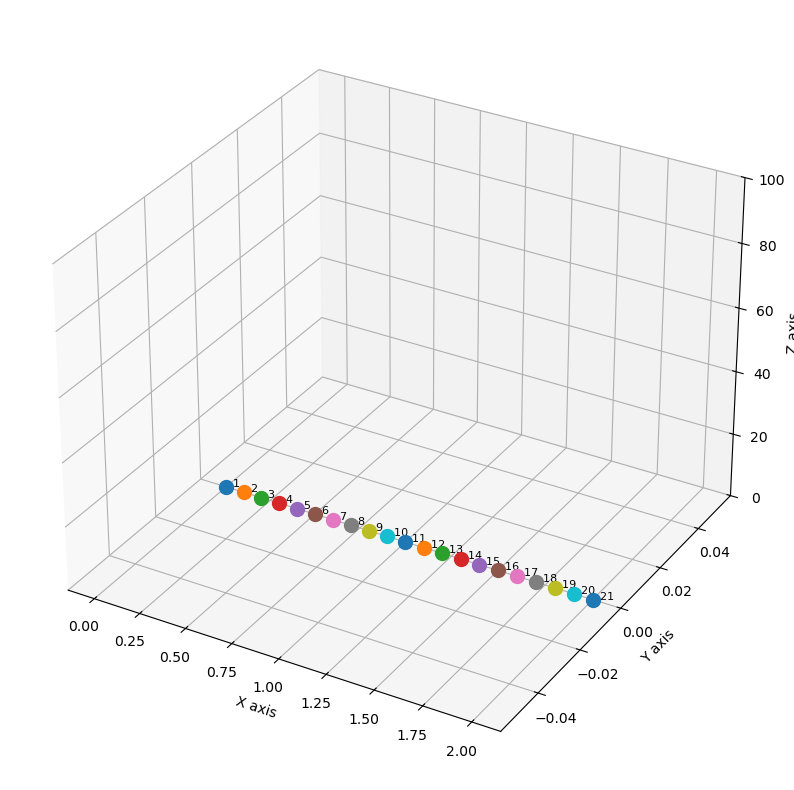

In [3]:
# Create nodes using a loop
nodes = []
for i in range(21):
    nodes.append(n.nodes(i * 0.1, 0, 0))

# Unpack nodes to individual variables for compatibility with existing code
n1, n2, n3, n4, n5, n6, n7, n8, n9, n10, n11, n12, n13, n14, n15, n16, n17, n18, n19, n20, n21 = nodes[:21]

n.plot_nodes(nodes)

In [4]:

E=210e9
rho=7850
b=0.05
h=0.1
A=b*h
Iy=b*h**3/12
Iz=h*b**3/12
It = b*h**3 * (1 - 0.63 * (h / b) * (1 - (h**4 / (12 * b**4))))
L = 0.1
Ip = Iy + Iz
k = 5/6 
G= E/(2*(1+0.3))


ep_K = [E, G, A, Iy, Iz, It, k]
ep_M = [rho, A, Iy, Iz, Ip]



In [5]:
elements = [(n1, n2, ep_K, ep_M), (n2, n3, ep_K, ep_M), (n3, n4, ep_K, ep_M), (n4, n5, ep_K, ep_M),
            (n5, n6, ep_K, ep_M), (n6, n7, ep_K, ep_M), (n7, n8, ep_K, ep_M), (n8, n9, ep_K, ep_M),
            (n9, n10, ep_K, ep_M), (n10, n11, ep_K, ep_M), (n11, n12, ep_K, ep_M), (n12, n13, ep_K, ep_M),
            (n13, n14, ep_K, ep_M), (n14, n15, ep_K, ep_M), (n15, n16, ep_K, ep_M), (n16, n17, ep_K, ep_M), (n17, n18, ep_K, ep_M),
            (n18, n19, ep_K, ep_M), (n19, n20, ep_K, ep_M), (n20, n21, ep_K, ep_M)]    

N = 21
DOF_per_node = 6

# K_global matrix
K_global = np.zeros((N*DOF_per_node, N*DOF_per_node))
M_global = np.zeros((N*DOF_per_node, N*DOF_per_node))

K_locs = []
M_locs = []
for i in range(len(elements)):
    _,_,M_loc, K_loc = e.elements(*elements[i])  
    K_locs.append(K_loc)
    M_locs.append(M_loc)

for i, K_loc in enumerate(K_locs):
    # Start DOF for first node of element
    start_dof = i * DOF_per_node
    # End DOF covers both nodes of the element
    end_dof = start_dof + 2*DOF_per_node
    
    # Add element stiffness into the global matrix
    K_global[start_dof:end_dof, start_dof:end_dof] += K_loc
    M_global[start_dof:end_dof, start_dof:end_dof] += M_loc


In [6]:
# Remove all rotations around the x-axis (torsional DOFs) for all nodes


# remove_DOFs = np.sort(list(range(3, 126, 4)) + list(range(0, 3)) + list(range(N*DOF_per_node - 6, N*DOF_per_node-3)))
# keep_DOFS = np.array([i for i in range(N*DOF_per_node) if i not in remove_DOFs])
# print("Indices to remove:", remove_DOFs)
# print("keep_DOFS:", keep_DOFS)

remove_DOFs = [0, 1, 2, 120,121,122]
keep_DOFS = np.array([i for i in range(N*DOF_per_node) if i not in remove_DOFs])
print("Indices to remove:", remove_DOFs)
print("keep_DOBS:", keep_DOFS)

Indices to remove: [0, 1, 2, 120, 121, 122]
keep_DOBS: [  3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20
  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38
  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56
  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74
  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92
  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110
 111 112 113 114 115 116 117 118 119 123 124 125]


In [7]:
K_global_reduced = K_global[np.ix_(keep_DOFS, keep_DOFS)]
M_global_reduced = M_global[np.ix_(keep_DOFS, keep_DOFS)]


K_global_reduced = 0.5 * (K_global_reduced + K_global_reduced.T)
M_global_reduced = 0.5 * (M_global_reduced + M_global_reduced.T)

# K_scaled = K_global_reduced / np.max(K_global_reduced)
# M_scaled = M_global_reduced / np.max(K_global_reduced)


In [8]:
# Obtain the eigenvalues and eigenvectors of the reduced system
eigvals_global, eigvecs_global = eigh(K_global_reduced, M_global_reduced)
frequencies_global = np.sqrt(eigvals_global)
tol = 1e-6
positive = eigvals_global > tol
frequencies_global = frequencies_global[positive]
eigvecs_global = eigvecs_global[:, positive]

print("Natural frequencies (rad/s):", frequencies_global[0:10])
print("Natural frequencies (Hz):", frequencies_global[0:10]/(2*np.pi))

Natural frequencies (rad/s): [ 184.00727252  366.85225989  733.71775574 1449.2145403  1642.36934561
 2899.24191138 3195.49120392 4490.40561146 5528.6372009  6399.62711194]
Natural frequencies (Hz): [  29.28566699   58.38635055  116.77480766  230.64965769  261.39119974
  461.42868142  508.57822071  714.67024955  879.90993909 1018.53228881]


C:\Users\alami\AppData\Local\Temp\ipykernel_17608\1077918759.py:3: RuntimeWarning: invalid value encountered in sqrt
  frequencies_global = np.sqrt(eigvals_global)


In [9]:
eigvecs_full = e.expand_eigenvectors(eigvecs_global, keep_DOFS, N*DOF_per_node)
print("Expanded eigenvectors shape:", eigvecs_full.shape)


Expanded eigenvectors shape: (126, 119)


In [10]:
eigvecs_disp_full = e.extract_displacement(eigvecs_full, keep=3, skip=3)
eigvecs_full.shape

(126, 119)

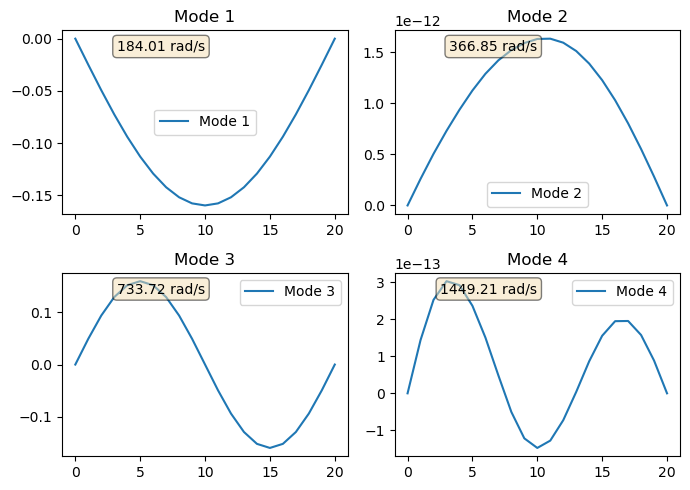

In [11]:
# plot modes in the y-direction
fig, axs = plt.subplots(2, 2, figsize=(7, 5))
axs[0, 0].plot(eigvecs_full[1::6, 0], label='Mode 1')
axs[0, 0].set_title('Mode 1')
axs[0, 0].legend()

axs[0, 1].plot(eigvecs_full[1::6, 1], label='Mode 2')
axs[0, 1].set_title('Mode 2')
axs[0, 1].legend()

axs[1, 0].plot(eigvecs_full[1::6, 2], label='Mode 3')
axs[1, 0].set_title('Mode 3')
axs[1, 0].legend()

axs[1, 1].plot(eigvecs_full[1::6, 3], label='Mode 4')
axs[1, 1].set_title('Mode 4')
axs[1, 1].legend()



plt.tight_layout()
plt.tight_layout()
for i in range(4):
    row, col = i // 2, i % 2
    freq_rad_s = frequencies_global[i]
    axs[row, col].text(0.5, 0.95, f'{freq_rad_s:.2f} rad/s', 
                       transform=axs[row, col].transAxes, 
                       verticalalignment='top', horizontalalignment='right',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

modes_to_plot = 5
modes = []
for i in range(modes_to_plot):
    modes.append(eigvecs_disp_full[:, i].reshape(-1, 3) + nodes)

element_nodes = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10),
                 (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17), (17, 18), (18, 19), (19, 20)]



In [12]:
#First ten modes
modes_to_plot = 5
modes = []
for i in range(modes_to_plot):
    modes.append(eigvecs_disp_full[:, i].reshape(-1, 3) + nodes)

element_nodes = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10),
                 (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17), (17, 18), (18, 19), (19, 20)]

In [13]:

for i in range(modes_to_plot):
    line_x = []
    line_y = []
    line_z = []
    for nA, nB in element_nodes:
        p1 = modes[i][nA - 1]
        p2 = modes[i][nB - 1]
        line_x.extend([p1[0], p2[0], None])
        line_y.extend([p1[1], p2[1], None])
        line_z.extend([p1[2], p2[2], None])

    fig_lines = go.Figure(
        data=[
            go.Scatter3d(
                x=line_x,
                y=line_y,
                z=line_z,
                mode='lines',
                line=dict(color='black', width=2)
            ),
            go.Scatter3d(
                x=modes[i][:, 0],
                y=modes[i][:, 1],
                z=modes[i][:, 2],
                mode='markers',
                marker=dict(size=3, color='blue')
            )
        ]
    )

    fig_lines.update_layout(
        title=f'Mode {i+1} - Deformed Configuration (Elements)',
        scene=dict(
            xaxis_title='X (m)',
            yaxis_title='Y (m)',
            zaxis_title='Z (m)'
        ),
        width=900,
        height=700
    )

    fig_lines.show()

In [14]:
print(np.shape(eigvecs_disp_full[0, :]))

(119,)
